<a href="https://colab.research.google.com/github/alracey/level4-project/blob/Higher-dimensions/coupling_layers_arena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dtype = torch.float32

Using device: cpu


In [3]:
import sys
sys.path.append('/content/drive/MyDrive')

In [4]:
import nf_code.coupling_layers as cl

In [5]:
def ring(x, y, r0=0.3, sigma = 0.05, centre=(0.5, 0.5)):    #soft-edged ring

  cx, cy = centre
  r = torch.sqrt((x-cx)**2 + (y-cy)**2)
  return torch.exp(-((r-r0)**2 / (2*(sigma)**2)))

tensor(1.1129)


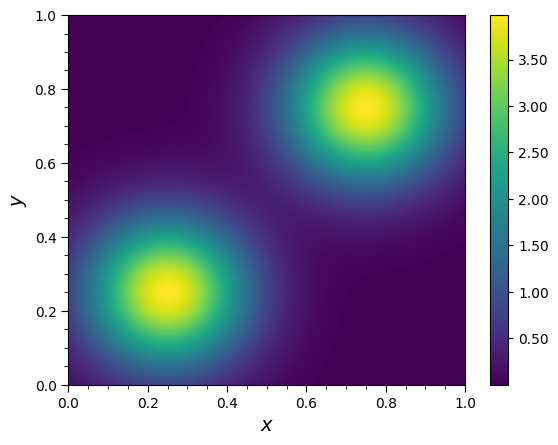

In [7]:
#plot camel function

cl.plot_f_2d(f=cl.camel, N=1000)

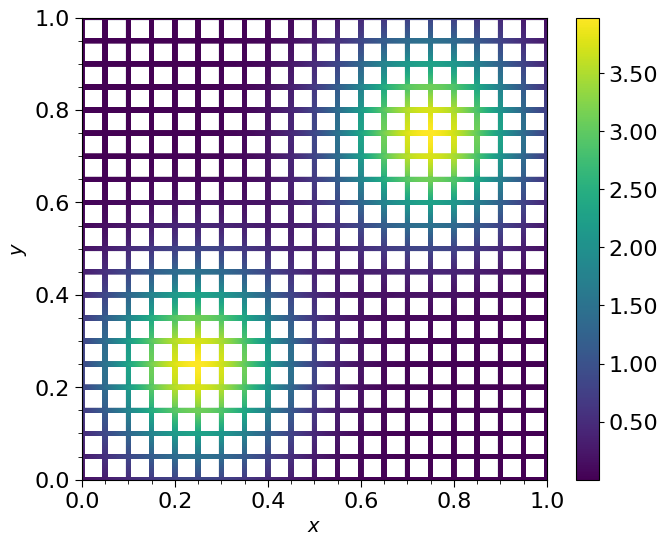

In [13]:
cl.plot_f_scatter_2d(f=cl.camel, n=3000, density=42)

Define flow parameters

In [8]:
A_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1])]

B_dims = [torch.tensor([1]),
          torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([0])]

#so 4 coupling layers, 2 dimensions



Train flow

In [9]:
final_loss, losses, flow = cl.train_loop_complete(
    f=cl.camel,
    D=2,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=32,
    hidden_size=16,
    N=10_000,
    epochs=2500,
    lr=1.3e-4,
    device=device,
    ticker=True
)

Epoch: 0 | Loss: 1.32058287e+00
Mean value:  0.9044138789176941
Epoch: 20 | Loss: 1.21756411e+00
Mean value:  0.8919498324394226
Epoch: 40 | Loss: 1.24228549e+00
Mean value:  0.9236378073692322
Epoch: 60 | Loss: 1.21059263e+00
Mean value:  0.9265939593315125
Epoch: 80 | Loss: 1.11595249e+00
Mean value:  0.9060859084129333
Epoch: 100 | Loss: 1.11893773e+00
Mean value:  0.9295238256454468
Epoch: 120 | Loss: 1.12099445e+00
Mean value:  0.9411686658859253
Epoch: 140 | Loss: 1.02344847e+00
Mean value:  0.9111443161964417
Epoch: 160 | Loss: 1.02309370e+00
Mean value:  0.9284845590591431
Epoch: 180 | Loss: 1.00991178e+00
Mean value:  0.9212263822555542
Epoch: 200 | Loss: 9.57680702e-01
Mean value:  0.9303743243217468
Epoch: 220 | Loss: 9.34899986e-01
Mean value:  0.9146457314491272
Epoch: 240 | Loss: 9.09951448e-01
Mean value:  0.9217031002044678
Epoch: 260 | Loss: 9.26273048e-01
Mean value:  0.9337393641471863
Epoch: 280 | Loss: 8.75817895e-01
Mean value:  0.935847282409668
Epoch: 300 | Loss

Plot results

In [14]:
Y = cl.grid_points_2d(3000, 42)

X, jacs = flow.inverse(Y)
X, jacs = X.detach(), jacs.detach()
X = X.T

h = cl.camel(*X) * jacs

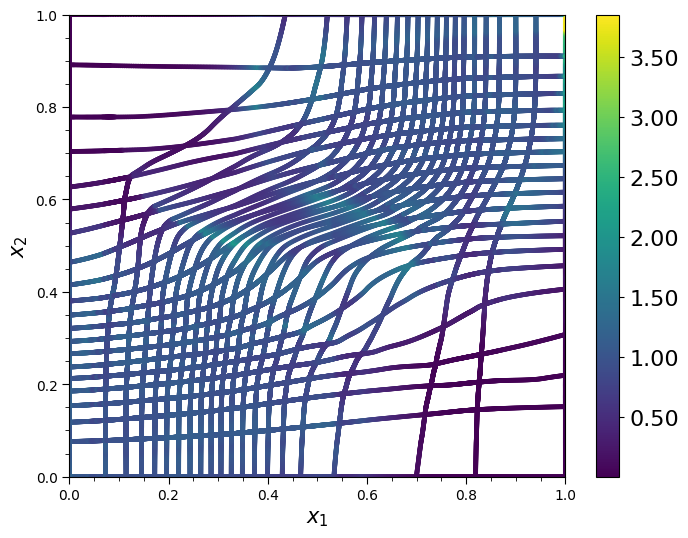

In [15]:
#distortion

cl.distortion_plot(X, h)

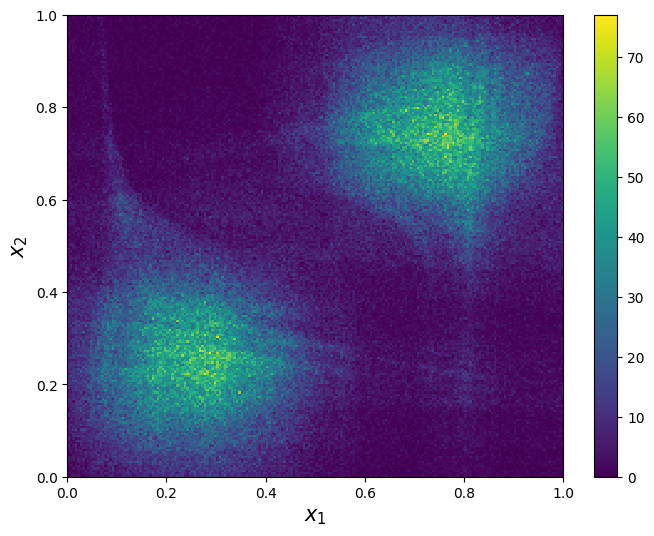

In [16]:
#effective sampling distribution

cl.plot_hist(flow=flow, num_samples=500000, bins=200, device=device)

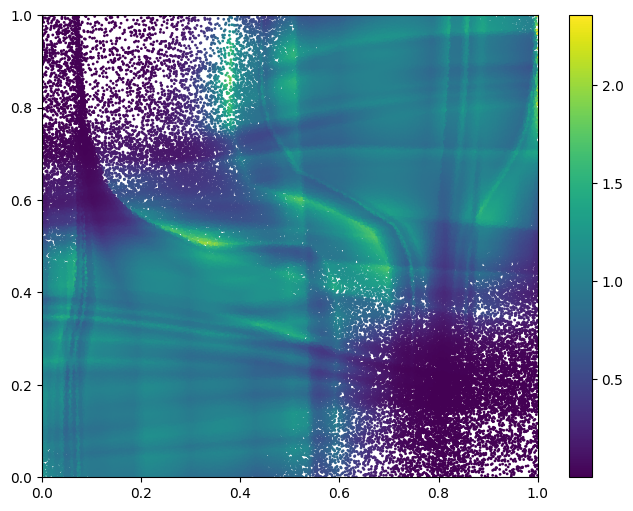

In [17]:
#distribution with weights shown

Y = torch.rand(500000, 2).to(device)
X, jacs = flow.inverse(Y)
X, jacs = X.detach(), jacs.detach()


cl.plot_weights(cl.camel, X, jacs)